# Random Forest Classification with `ranger`

## Overview

Random forests build an ensemble of decision trees, each trained on a bootstrap sample and a random subset of features. Predictions are aggregated by majority vote. The combination of bootstrap aggregation (bagging) and random feature selection reduces variance dramatically compared to single trees.

**Key advantages:**
- Strong predictive performance with minimal tuning
- Out-of-bag (OOB) error estimate is a nearly unbiased held-out error estimate — no separate validation set needed during training
- Permutation-based variable importance is unbiased for mixed variable types
- Handles missing data, mixed types, and high-dimensional inputs well

**`ranger` vs `randomForest`:** `ranger` is 2–10× faster, supports multithreading, and produces unbiased permutation importance. Prefer it for any non-trivial dataset.

**Key hyperparameters:**

| Parameter | Default | What it controls |
|---|---|---|
| `num.trees` | 500 | More trees = lower variance; 500–2000 typical |
| `mtry` | √p (classification) | Features considered per split; main tuning knob |
| `min.node.size` | 1 | Minimum terminal node size; increase to regularise |
| `max.depth` | unlimited | Tree depth; NULL = fully grown |

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(ranger)       # fast random forests
library(vip)          # variable importance plots
library(yardstick)
library(patchwork)

set.seed(42)

n <- 600
rf_data <- tibble(
  nitrate     = rnorm(n, 3, 1.2),
  water_qual  = rnorm(n, 6, 1.5),
  distance_km = rexp(n, 0.4),
  elevation   = rnorm(n, 200, 80),
  slope_pct   = abs(rnorm(n, 10, 5)),
  habitat     = factor(sample(c("reference","restored","degraded"), n,
                              replace=TRUE, prob=c(.35,.35,.30)),
                       levels=c("reference","restored","degraded")),
  noise1      = rnorm(n),   # irrelevant features
  noise2      = rnorm(n),
  log_odds    = -1 + 0.6*water_qual - 0.7*nitrate - 0.3*distance_km +
                0.01*elevation +
                case_when(habitat=="reference"~0.8, habitat=="restored"~0.2,
                          habitat=="degraded"~ -0.9),
  present     = factor(rbinom(n, 1, plogis(log_odds)),
                       levels=c(0,1), labels=c("absent","present"))
)

train_idx  <- sample(n, 450)
train_data <- rf_data[train_idx,]
test_data  <- rf_data[-train_idx,]

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'vip' was built under R version 4.4.3"

Attaching package: 'vip'


The following object is masked from 'pac

---

## Fit a Random Forest

In [2]:
rf_fit <- ranger(
  present ~ nitrate + water_qual + distance_km + elevation +
             slope_pct + habitat + noise1 + noise2,
  data             = train_data,
  num.trees        = 1000,
  mtry             = 3,              # ~√8 predictors; tune below
  min.node.size    = 5,              # classification default = 1; 5 adds regularisation
  importance       = "permutation",  # unbiased; also: "impurity", "impurity_corrected"
  probability      = TRUE,           # return probability predictions (not class)
  num.threads      = 4,
  seed             = 42
)

cat(sprintf("OOB prediction error: %.4f\n", rf_fit$prediction.error))
# OOB error is a nearly unbiased estimate of test error
# For probability forests: OOB Brier score (lower = better)
# For classification forests (probability=FALSE): OOB misclassification rate

print(rf_fit)

OOB prediction error: 0.1391
Ranger result

Call:
 ranger(present ~ nitrate + water_qual + distance_km + elevation +      slope_pct + habitat + noise1 + noise2, data = train_data,      num.trees = 1000, mtry = 3, min.node.size = 5, importance = "permutation",      probability = TRUE, num.threads = 4, seed = 42) 

Type:                             Probability estimation 
Number of trees:                  1000 
Sample size:                      450 
Number of independent variables:  8 
Mtry:                             3 
Target node size:                 5 
Variable importance mode:         permutation 
Splitrule:                        gini 
OOB prediction error (Brier s.):  0.1391161 


---

## Tuning `mtry`

# A tibble: 4 × 2
   mtry oob_brier
  <dbl>     <dbl>
1     1     0.140
2     2     0.137
3     4     0.140
4     8     0.140
Best mtry: 2


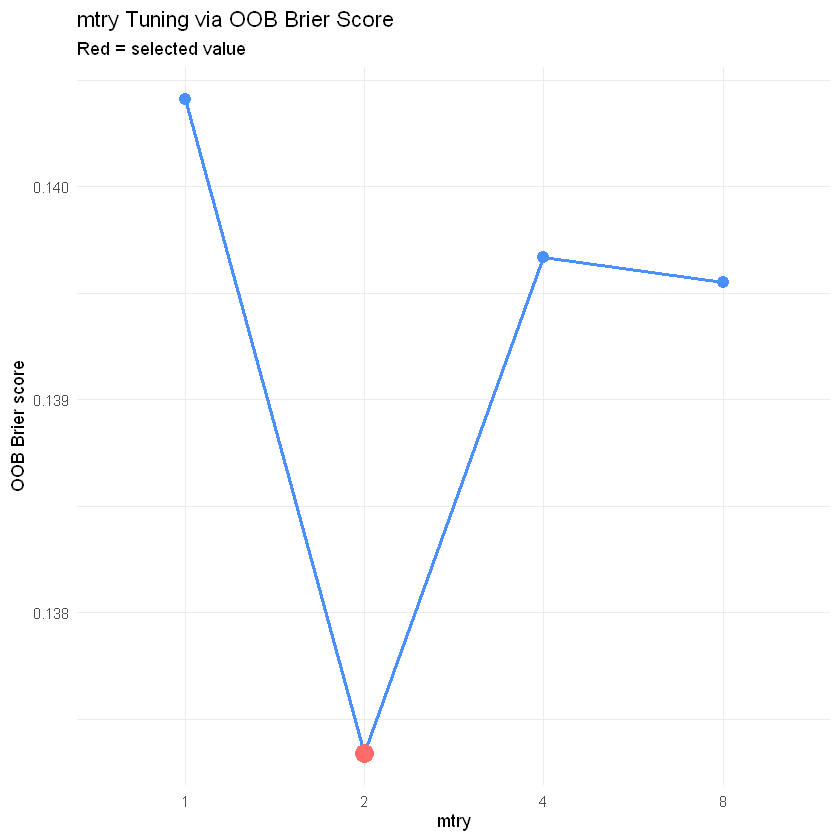

In [3]:
# mtry is the most important hyperparameter for random forests
# Tune by OOB error over a grid (no cross-validation needed)

p_features <- 8   # number of predictors
mtry_grid  <- unique(c(1, floor(sqrt(p_features)), floor(p_features/3),
                        floor(p_features/2), p_features))

mtry_results <- map_dfr(mtry_grid, function(m) {
  rf <- ranger(
    present ~ nitrate + water_qual + distance_km + elevation +
               slope_pct + habitat + noise1 + noise2,
    data=train_data, num.trees=500, mtry=m,
    min.node.size=5, probability=TRUE,
    num.threads=4, seed=42
  )
  tibble(mtry=m, oob_brier=rf$prediction.error)
})

print(mtry_results)
best_mtry <- mtry_results %>% slice_min(oob_brier) %>% pull(mtry)
cat(sprintf("Best mtry: %d\n", best_mtry))

ggplot(mtry_results, aes(x=factor(mtry), y=oob_brier, group=1)) +
  geom_line(color="#4a8fff", linewidth=1) +
  geom_point(size=3, color="#4a8fff") +
  geom_point(data=~filter(.x, mtry==best_mtry),
             color="#ff6b6b", size=5) +
  labs(title="mtry Tuning via OOB Brier Score",
       subtitle="Red = selected value",
       x="mtry", y="OOB Brier score") +
  theme_minimal()

---

## Variable Importance

# A tibble: 2 × 3
  .metric  .estimator .estimate
  <chr>    <chr>          <dbl>
1 accuracy binary         0.8  
2 kap      binary         0.316
# A tibble: 1 × 3
  .metric .estimator .estimate
  <chr>   <chr>          <dbl>
1 roc_auc binary         0.845


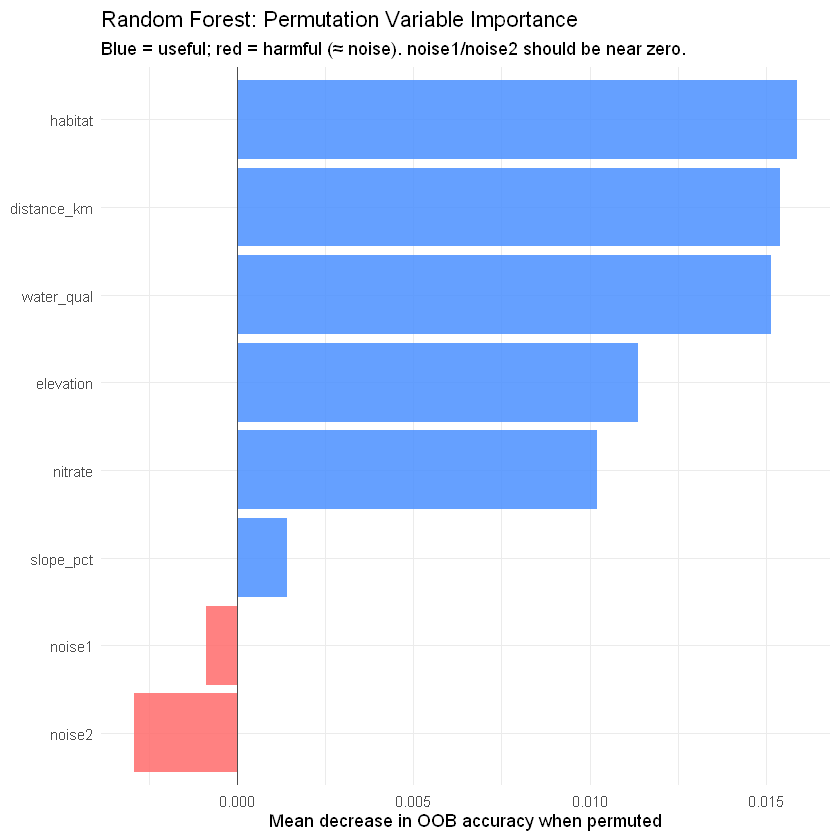

In [4]:
# Fit final model with best mtry
rf_final <- ranger(
  present ~ nitrate + water_qual + distance_km + elevation +
             slope_pct + habitat + noise1 + noise2,
  data=train_data, num.trees=1000, mtry=best_mtry,
  min.node.size=5, importance="permutation",
  probability=TRUE, num.threads=4, seed=42
)

# ── Permutation importance ────────────────────────────────────────────────────
# Mean decrease in OOB accuracy when each variable is randomly permuted
# Positive: variable is useful; negative: variable adds noise
vi_df <- tibble(
  variable   = names(rf_final$variable.importance),
  importance = rf_final$variable.importance
) %>% arrange(importance)

ggplot(vi_df, aes(x=importance,
                  y=fct_reorder(variable, importance),
                  fill=importance > 0)) +
  geom_col(alpha=0.85) +
  scale_fill_manual(values=c("TRUE"="#4a8fff", "FALSE"="#ff6b6b"),
                    guide="none") +
  geom_vline(xintercept=0, color="gray30") +
  labs(title="Random Forest: Permutation Variable Importance",
       subtitle="Blue = useful; red = harmful (≈ noise). noise1/noise2 should be near zero.",
       x="Mean decrease in OOB accuracy when permuted", y=NULL) +
  theme_minimal()

# ── Test set evaluation ───────────────────────────────────────────────────────
test_preds <- test_data %>%
  mutate(
    prob_present = predict(rf_final, data=test_data)$predictions[,"present"],
    pred_class   = factor(ifelse(prob_present >= 0.5, "present","absent"),
                          levels=c("absent","present"))
  )

yardstick::metrics(test_preds, truth=present, estimate=pred_class) %>% print()
yardstick::roc_auc(test_preds, truth=present, prob_present,
                   event_level="second") %>% print()

---

## Common Pitfalls

**1. Using impurity importance instead of permutation importance**  
Impurity importance (`importance="impurity"`) is biased toward variables with many possible split points (continuous variables over binary ones). Use `importance="permutation"` for unbiased ranking, especially with mixed variable types.

**2. Not checking that `num.trees` is large enough for OOB error to stabilise**  
OOB error is noisy with too few trees. Plot OOB error vs. number of trees with `ranger` by fitting with `keep.inbag=TRUE` or iteratively. For most problems, 500–1000 trees is sufficient; 2000+ rarely helps.

**3. Treating OOB error as identical to test set error**  
OOB error is nearly unbiased but is estimated on individual tree predictions, not the full ensemble. It tends to slightly overestimate the ensemble test error. Always confirm on a held-out test set before reporting.

**4. Not tuning `mtry`**  
The default `mtry = √p` is a good starting point but not always optimal. For datasets with many correlated features or where most features are noise, a smaller `mtry` often performs better. Tune over a 5-point grid using OOB Brier score.

**5. Using random forests for formal statistical inference**  
Random forests do not produce p-values or confidence intervals for variable importance. Permutation importance is a predictive measure, not an inferential one. For inference on individual predictors, use regression models. For exploratory variable screening, random forests are appropriate.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*